# 02 Target Definition

Sprint 2 — build the supervised target dataset at `(player_id, valuation_date)` level.

Each row pairs a player's current valuation with their **next** historical valuation. No feature engineering, no joins beyond `player_valuations`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import INTERIM_DATA_DIR, METRICS_DIR
from src.load_data import load_raw_datasets
from src.build_dataset import (
    build_target_dataset,
    build_target_summary,
    prepare_valuations,
    save_target_dataset,
    save_target_summary,
)

In [2]:
datasets = load_raw_datasets()
pv = datasets['player_valuations']
print('player_valuations shape:', pv.shape)
pv.head()

Loading raw datasets from C:\football_market_value-dl\data\raw
  loaded players.csv.gz: shape=(47637, 26)
  loaded player_valuations.csv.gz: shape=(507815, 6)
  loaded appearances.csv.gz: shape=(1877839, 13)
  loaded games.csv.gz: shape=(88271, 23)
  loaded clubs.csv.gz: shape=(796, 17)
  loaded competitions.csv.gz: shape=(67, 11)
player_valuations shape: (507815, 6)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


## Duplicate inspection on `(player_id, date)`

In [3]:
cleaned = prepare_valuations(pv)
print('rows before prepare_valuations:', len(pv))
print('rows after prepare_valuations :', len(cleaned))
print('rows dropped (NaN, <=0, dups) :', len(pv) - len(cleaned))

rows before prepare_valuations: 507815
rows after prepare_valuations : 507814
rows dropped (NaN, <=0, dups) : 1


## Build the (current, next) target table

In [4]:
target = build_target_dataset(datasets)
print('target shape:', target.shape)
target.head()

target shape: (476307, 14)


,player_id,valuation_date,market_value_in_eur,next_valuation_date,next_market_value_in_eur,log_market_value,log_next_market_value,days_to_next_valuation,value_change_abs,value_change_pct,log_value_change,current_club_id,player_club_domestic_competition_id,current_club_name
0,10,2004-10-04,7000000,2005-01-07,9000000.0,15.761421,16.012735,95,2000000.0,0.285714,0.251314,398,IT1,SV Werder Bremen
1,10,2005-01-07,9000000,2005-05-05,12000000.0,16.012735,16.300417,118,3000000.0,0.333333,0.287682,398,IT1,SV Werder Bremen
2,10,2005-05-05,12000000,2005-09-30,15000000.0,16.300417,16.523561,148,3000000.0,0.250000,0.223144,398,IT1,SV Werder Bremen
3,10,2005-09-30,15000000,2006-01-09,20000000.0,16.523561,16.811243,101,5000000.0,0.333333,0.287682,398,IT1,SV Werder Bremen
4,10,2006-01-09,20000000,2006-07-15,30000000.0,16.811243,17.216708,187,10000000.0,0.500000,0.405465,398,IT1,SV Werder Bremen


## Distribution of the target and time gap

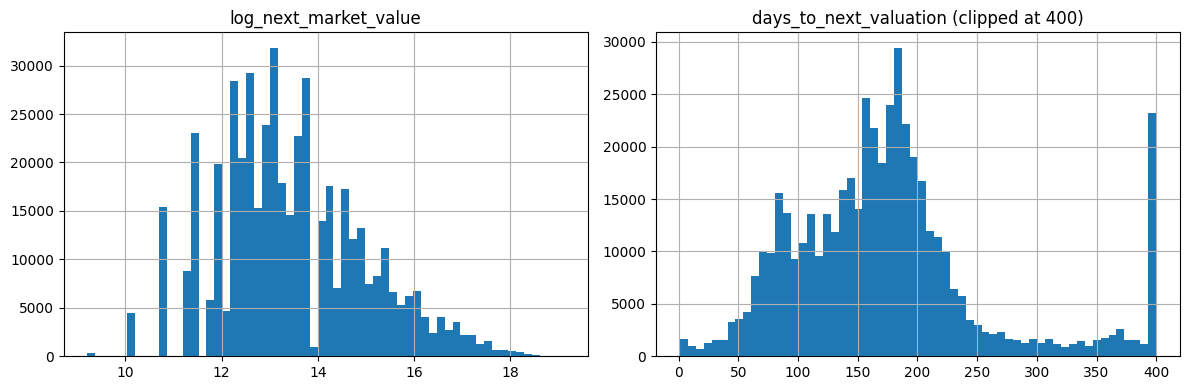

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target['log_next_market_value'].hist(bins=60, ax=axes[0])
axes[0].set_title('log_next_market_value')
target['days_to_next_valuation'].clip(upper=400).hist(bins=60, ax=axes[1])
axes[1].set_title('days_to_next_valuation (clipped at 400)')
plt.tight_layout()
plt.show()

## Persist artefacts

In [6]:
save_target_dataset(target, INTERIM_DATA_DIR / 'valuation_targets.parquet')
summary = build_target_summary(target)
save_target_summary(summary, METRICS_DIR / 'target_summary.json')
summary

Target dataset written to C:\football_market_value-dl\data\interim\valuation_targets.parquet
CSV mirror written to C:\football_market_value-dl\data\interim\valuation_targets.csv
Target summary written to C:\football_market_value-dl\reports\metrics\target_summary.json


{'rows': 476307,
 'unique_players': 30637,
 'min_valuation_date': '2000-01-20',
 'max_valuation_date': '2025-12-19',
 'min_next_valuation_date': '2004-10-04',
 'max_next_valuation_date': '2026-02-27',
 'min_days_to_next_valuation': 1,
 'median_days_to_next_valuation': 168.0,
 'max_days_to_next_valuation': 5862,
 'target_min': 10000.0,
 'target_median': 600000.0,
 'target_mean': 2677953.313722032,
 'target_max': 200000000.0,
 'log_target_min': 9.210440366976517,
 'log_target_median': 13.304686600863562,
 'log_target_mean': 13.466719937308474,
 'log_target_max': 19.11382792951231}